In [1]:
import torch
import json
import os

from data.ae_dataset import AEDataset
from torch import linalg as LA
import numpy as np
from matplotlib.pyplot import plot
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown, display_markdown # to display images

# Global variable

In [33]:
rec_seq = torch.load("model_outputs/rec_seq_real_0724_204251_v9.pt")   # [10377, 10, 512]

ori_seq = torch.load("model_outputs/ori_seq_0724_204251_v9.pt")   # [10377, 10, 512]

all_emb_path = os.path.join("./processed_data", "mean_pooled_emb.pt")
all_emb = torch.load(all_emb_path)   # [141245, 512]

all_md_path = os.path.join("./processed_data", "emb_idx_filtered.json")
with open(all_md_path, 'r') as fp:
    all_md = json.load(fp)   # .shape[0]=141245

In [34]:
def compute_aid_to_part_indice_map():
    the_map = dict()
    assert len(all_md) == all_emb.shape[0]
    for idx, md in enumerate(all_md):
        aid = '_'.join(md.split('_')[1:3])
        if aid in the_map:
            the_map[aid].append(idx)
        else:
            the_map[aid] = []
            the_map[aid].append(idx)
    
    return the_map

aid_to_part_indice_map = compute_aid_to_part_indice_map()   # 8146: # assemblies got successfully processed/rendered

len(aid_to_part_indice_map)

8146

In [35]:
def compute_md_to_idx_map():
    the_map = dict()
    for idx, md in enumerate(all_md):
        the_map[md] = idx
    
    return the_map

md_to_idx_map = compute_md_to_idx_map()
len(md_to_idx_map)

141245

In [36]:
with open('./processed_data/part_graphs_dim=5.json') as fp:
    all_part_graph = json.load(fp)

valid_aid_list = list(all_part_graph.keys())   # 5462: # assemblies having contact info, also # assemblies in the part graph

# Display norm

In [10]:
# For rec_seq
all_rec_norm_list = []
for seq in rec_seq:
    # seq: [10, 512]
    norm_list = []
    for emb in seq:
        # emb: [512]
        norm_list.append(LA.norm(emb).item())
    all_rec_norm_list.append(norm_list)

# For ori_seq
all_ori_norm_list = []
for seq in ori_seq:
    # seq: [10, 512]
    norm_list = []
    for emb in seq:
        # emb: [512]
        norm_list.append(LA.norm(emb).item())
    all_ori_norm_list.append(norm_list)

In [11]:
assert len(all_rec_norm_list) == len(all_ori_norm_list)

In [ ]:
all_rec_norm_list[9]

In [ ]:
plot(range(10), all_rec_norm_list[9])

# Find the closest part

In [6]:
# find the pad for ori, compute the 'mask'
eps = 0.5
threshold = 0.5

## 1. Find part in the entire part embedding space

In [37]:
def find_closest(emb, indices=list(range(len(all_emb)))):
    delta = all_emb - emb   # [141245, 512]
    dist = LA.norm(delta, dim=1)   #[141245]
    indices = torch.LongTensor(indices)
    min_val = torch.min(torch.index_select(dist, 0, indices)).item()
#     print(f'min: {dist[indices].min()}, max: {dist[indices].max()}')
#     idx = dist.argmin()   # If there are multiple minimal values then the indices of the first minimal value are returned.
    idx_tuple = (dist == min_val).nonzero(as_tuple=True)[0]   # first [0]: (tensor([91286]),) second[0]: remove multiple values
    for idx in idx_tuple:
        if idx in indices:
            return idx.item(), dist[idx].item()
    
    idx = idx_tuple[0]
    return idx.item(), dist[idx].item()

In [38]:
all_rec_closest_emb_list = []
for i, seq in tqdm(enumerate(rec_seq[:10, :, :])):
    closest_emb_list = []
    for j, rec_emb in enumerate(seq):
        if all_rec_norm_list[i][j] < eps:
            break
        closest_emb_idx, _ = find_closest(rec_emb)
        closest_emb_list.append(closest_emb_idx)
    all_rec_closest_emb_list.append(closest_emb_list)

10it [00:02,  4.66it/s]


In [39]:
all_ori_closest_emb_list = []
for i, seq in tqdm(enumerate(ori_seq[:10, :, :])):
    closest_emb_list = []
    for j, ori_emb in enumerate(seq):
        if all_ori_norm_list[i][j] < eps:
            break
        closest_emb_idx, _ = find_closest(ori_emb)
        closest_emb_list.append(closest_emb_idx)
    all_ori_closest_emb_list.append(closest_emb_list)

10it [00:03,  2.82it/s]


In [40]:
all_rec_closest_emb_list[:10]

[[129259, 129260, 6252],
 [129260, 129259, 6252],
 [96139, 96143, 15037, 96149],
 [96140, 93321],
 [96141, 96143],
 [96142, 96143],
 [106573, 116576],
 [96146, 96143],
 [96147, 96143],
 [96149, 96143, 96139]]

In [41]:
all_ori_closest_emb_list

[[129259, 129260],
 [129260, 129259],
 [96139, 96143, 96146, 96148, 96149],
 [96140, 96147, 96142, 96143, 96151, 96148, 96149, 96141],
 [96141, 96143, 96140],
 [96142, 96143, 96140],
 [96143, 96147, 96142, 96150, 96151, 96152, 96146, 96139, 96148, 96149],
 [96146, 96143, 96139],
 [96147, 96143, 96140],
 [96148, 96143, 96139, 96140]]

In [33]:
all_md[129259]

'0000_79682_b75071d6_cf962214-059a-11ec-9f7a-02631ee0d5cb_0000'

## 2. Find part in the same assembly (top-k)

In [55]:
def find_topk_closest(emb, k=10):
    
    delta = all_emb - emb   # [141245, 512]
    dist = LA.norm(delta, dim=1)   # [141245]
    sorted_dist, indices = torch.sort(dist)
    topk_indices = indices[:k]   # The k closest (out of all) part embedding's indices
    
    return topk_indices

In [56]:
def find_part(emb, ind):

    img_name = all_md[ind]
    aid = '_'.join(img_name.split('_')[1:3])
    constraint_indices = aid_to_part_indice_map[aid]
    part_idx, _ = find_closest(emb, constraint_indices)
    
    return part_idx
    

In [57]:
all_decoded_seq_list = []   # list of list of list

for i, seq in tqdm(enumerate(rec_seq[:10, :, :])):   # for each reconstructed part embedding sequence
    candi_part_indices = find_topk_closest(seq[0])   # find topk closest part embedding of the central part embedding
    decoded_seq_list = []   # list of list
    for candi_part_index in candi_part_indices:
        decoded_seq = []   # store the decoded seq constrained by candi_part_index
        decoded_seq.append(candi_part_index.item())
        for j, rec_emb in enumerate(seq):   # for each neighbouring part embedding
            if j==0:   # Skip decoding the first(central) part embedding
                continue
            
            if all_rec_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
                break
            
            part_idx = find_part(rec_emb, candi_part_index)   # find the closest part index constrained by candi_part_index
            decoded_seq.append(part_idx)
            
        decoded_seq_list.append(decoded_seq)   # add the decoded_seq
            
    all_decoded_seq_list.append(decoded_seq_list)

10it [00:11,  1.20s/it]


In [58]:
all_decoded_seq_list[0]

[[129259, 129260, 129259],
 [53817, 53818, 53812],
 [55125, 55134, 55136],
 [302, 303, 302],
 [124397, 124386, 124389],
 [43462, 43462, 43462],
 [109474, 109476, 109471],
 [93736, 93732, 93740],
 [54639, 54648, 54642],
 [95565, 95560, 95556]]

## 3. Find part in the same assembly for all assemblies

In [62]:
def compute_decoded_seq(seq_idx, seq, indices):
    decoded_seq = []
    total_dist = 0.0
    total = 0
    for j, emb in enumerate(seq):
        if all_rec_norm_list[seq_idx][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
            break
        if len(indices)==0:
            break
        idx, local_dist = find_closest(emb, indices)
        decoded_seq.append(idx)
        total_dist += local_dist
#         print(indices)
#         print(idx)
        indices.remove(idx)
        total += 1
    
    return decoded_seq, total_dist / total if total != 0 else 100000

In [ ]:
# very slow implementation - 30 min/it
all_decoded_seq_list = []
for i, seq in tqdm(enumerate(rec_seq[:1, :, :])):
    all_decoded_seq_dict = dict()   # decoded_seq_within_aid: avg_dist
    for aid, indices in tqdm(aid_to_part_indice_map.items()):
        decoded_seq, avg_dist = compute_decoded_seq(i, seq, indices.copy())
        all_decoded_seq_dict[aid] = (decoded_seq, avg_dist)
    all_decoded_seq_list.append(all_decoded_seq_dict)

In [ ]:
print(all_decoded_seq_list)

In [ ]:
a = sorted(all_decoded_seq_list[0].items(), key=lambda x: x[1][1])
print(a[:10])

In [ ]:
print(aid_to_part_indice_map)

In [63]:
# a faster implementation - 17 s/it
all_decoded_seq_list = []
for i, seq in tqdm(enumerate(rec_seq[:10, :, :])):
    seq_dist = []
    for j, rec_emb in enumerate(seq):
        delta = all_emb - rec_emb   # [141245, 512]
        emb_dist = LA.norm(delta, dim=1)
        seq_dist.append(emb_dist)
    
    seq_dist = torch.stack(seq_dist, dim=1)   # [141245, 10]
    all_decoded_seq_dict = dict()
    for aid in valid_aid_list:
        indices = aid_to_part_indice_map[aid]
        decoded_seq = []
        indices = indices.copy()
        total_dist = 0.0
        total = 0
        # sequential search
        for j, rec_emb in enumerate(seq):
            if all_rec_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
                break
            if len(indices)==0:
                break
            min_val = torch.min(torch.index_select(seq_dist[:, j], 0, torch.LongTensor(indices))).item()
            idx_tuple = (seq_dist == min_val).nonzero(as_tuple=True)[0]   # first [0]: (tensor([91286]),) second[0]: remove multiple values
            for idx in idx_tuple:   # will find one for sure
                if idx in indices:
                    decoded_seq.append(idx.item())
                    total_dist += seq_dist[idx, j].item()
                    break
            indices.remove(idx)
            total += 1
        all_decoded_seq_dict[aid] = (decoded_seq, total_dist / total if total != 0 else 100000)
    all_decoded_seq_list.append(all_decoded_seq_dict)

10it [02:52, 17.23s/it]


In [ ]:
print(all_decoded_seq_list[1])

In [20]:
a = sorted(all_decoded_seq_list[8].items(), key=lambda x: x[1][1])
print(a[:10])

[('135445_77b4ac77', ([25684, 25656], 0.1278623826801777)), ('54065_e3f36560', ([110888, 110892], 0.12809928506612778)), ('52766_019fd239', ([108823, 108815], 0.12919281795620918)), ('33973_0bcf43ee', ([85045, 85058], 0.12936382740736008)), ('136793_6f575b30', ([28227, 28233], 0.12956888228654861)), ('22056_79373464', ([52821, 52864], 0.12997572869062424)), ('41504_85e300ee', ([94027, 94026], 0.13035663217306137)), ('51244_55712a1c', ([105494, 105492], 0.1306457817554474)), ('131762_9b5e5ff5', ([19157, 19179], 0.13091463968157768)), ('139371_557edc08', ([32183, 32175], 0.1318661943078041))]


In [ ]:
# a greedy search implementation - 30 s/it
# haven't implemented yet
all_decoded_seq_list = []
for i, seq in tqdm(enumerate(rec_seq[:1, :, :])):
    seq_dist = []
    for j, rec_emb in enumerate(seq):
        delta = all_emb - rec_emb   # [141245, 512]
        emb_dist = LA.norm(delta, dim=1)
        seq_dist.append(emb_dist)
    
    seq_dist = torch.stack(seq_dist, dim=1)   # [141245, 10]
    all_decoded_seq_dict = dict()
    for aid, indices in aid_to_part_indice_map.items():
#         dist_local = dist_seq[indices = torch.LongTensor(indices)]
        decoded_seq = []
        indices = indices.copy()
        total_dist = 0.0
        total = 0
        # greedy search
#         for j, rec_emb in enumerate(seq):
#             if all_rec_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
#                 break
#             if len(indices)==0:
#                 break
#             min_val = torch.min(torch.index_select(seq_dist[:, j], 0, torch.LongTensor(indices))).item()
#             idx_tuple = (seq_dist == min_val).nonzero(as_tuple=True)[0]   # first [0]: (tensor([91286]),) second[0]: remove multiple values
#             for idx in idx_tuple:
#                 if idx in indices:
#                     decoded_seq.append(idx.item())
#                     total_dist += seq_dist[idx, j].item()
#                     break
#             indices.remove(idx)
#             total += 1
        all_decoded_seq_dict[aid] = (decoded_seq, total_dist / total if total != 0 else 100000)
    all_decoded_seq_list.append(all_decoded_seq_dict)

# Evaluation - IOU
## Corresponding to 3.

In [ ]:
decoded_seq = sorted(all_decoded_seq_list[0].items(), key=lambda x: x[1][1])
print(decoded_seq[:20])

In [64]:
def transform(part_graph_dict):
    returned_dict = dict()
    for c_md, n_md_list in part_graph_dict.items():
        idx_list = []
        for n_md in n_md_list:
            idx_list.append(md_to_idx_map[n_md])
    
        returned_dict[md_to_idx_map[c_md]] = idx_list
    
    return returned_dict

In [65]:
def compute_iou(y_pred, y_true, dup_map, epsilon=1e-6):
    y_pred = set(y_pred)
    y_true = set(y_true)
    len_pred = len(y_pred)
    len_true = len(y_true)
    
#     intersection = y_pred.intersection(y_true)

    intersection = []
    for part_idx_true in y_true:
        for part_idx_pred in y_pred:
            if part_idx_true in dup_map[part_idx_pred]:
                intersection.append(part_idx_true)
            
    union = y_pred.union(y_true)
    
    iou_rec = len(intersection) / len_pred
    iou_prec = len(intersection) / len_true
    iou_score = len(intersection) / len(union)
    
    return 2 * iou_prec * iou_rec / (iou_prec + iou_rec + epsilon), iou_score#, len(union)

In [66]:
def search_duplicate(c_part_idx, aid, eps=1e-3):
    indices = aid_to_part_indice_map[aid]
    start_idx = indices[0]
    embs = all_emb[indices]
    cdist = torch.cdist(embs, embs, p=2)
    indices = torch.LongTensor(indices)
    c_part_dup_list = indices[torch.LongTensor((cdist[c_part_idx-start_idx]<eps).nonzero(as_tuple=True)[0])].tolist()
    
    return c_part_dup_list

In [75]:
k = 1
for decoded_seq_dict in all_decoded_seq_list:
    ordered_decoded_seq = sorted(decoded_seq_dict.items(), key=lambda x: x[1][1])   # [(aid, (seq_list, avg_dist))]
    ordered_topk_decoded_seq = ordered_decoded_seq[:k]   # [(aid, (seq_list, avg_dist))]
    iou = 0.0
    total_iou = 0.0
    total_iou_score = 0.0
    total_length_union = 0.0
    total = 0.0
    for aid, (seq, avg_dist) in ordered_topk_decoded_seq:
        aid_part_graph = all_part_graph[aid]   # obtain all the part graphs associated with aid
        aid_part_graph = transform(aid_part_graph)   # md --> idx
        c_part = seq[0]   # central part idx
        n_parts_pred = seq[1:]   # a list of neighbouring part indices
#         c_part_dup_list = search_duplicate(c_part, aid)
#         total += len(c_part_dup_list)
        max_iou = 0
        max_iou_score = 0
#         cur_length_union = 0
        
        dup_map = dict()
        for part_idx in seq:
            dup_map[part_idx] = search_duplicate(part_idx, aid)
            
        for c_part in dup_map[c_part]:
            if c_part in aid_part_graph:   # if aid_part_graph contains c_part in the decoded seq
                n_parts_true = aid_part_graph[c_part][:9]
                
                iou, iou_score = compute_iou(n_parts_pred, n_parts_true, dup_map)
                if iou > max_iou:
                    total_iou += iou
                    total_iou_score += iou_score
#                     total_length_union += union
#     print(total)
    print(f'iou: {total_iou / k}, iou_score: {total_iou_score / k}')#', union length: {total_length_union/k}')

iou: 0.99999950000025, iou_score: 1.0
iou: 0.99999950000025, iou_score: 1.0
iou: 0.8571423673472187, iou_score: 0.75
iou: 0.24999978125019143, iou_score: 0.14285714285714285
iou: 0.6666662222225186, iou_score: 0.5
iou: 0.6666662222225186, iou_score: 0.5
iou: 0.199999820000162, iou_score: 0.1111111111111111
iou: 0.6666662222225186, iou_score: 0.5
iou: 0.6666662222225186, iou_score: 0.5
iou: 0.7999995200002881, iou_score: 0.6666666666666666


In [128]:
aid = '20176_a02bde39'
indices = aid_to_part_indice_map[aid]
embs = all_emb[indices]
print(embs.shape)
cdist = torch.cdist(embs, embs, p=2)
indices = torch.LongTensor(indices)
indices[torch.LongTensor((cdist[7]<1e-3).nonzero(as_tuple=True)[0])].tolist()

torch.Size([38, 512])


[46158, 46159]

# Evaluation - Display parts

In [25]:
def image_grid(imgs, rows, cols, resize=False, texts=None):
        
    if resize:
        scale = 1/3
        w, h = imgs[0].size
        newsize = (int(w*scale), int(h*scale))
        imgs = [ img.resize(newsize) for img in imgs]

    # Width and height of the (first) image
    w, h = imgs[0].size

    # Calculate grid width and height
    grid_w = cols*w   # number of columns * width
    grid_h = rows*h
    grid = Image.new('RGB', size=(grid_w, grid_h), color="white")

    # Draw the grid
    I1 = ImageDraw.Draw(grid)
    
    for i, img in enumerate(imgs):
        x = i%cols*w
        y = i//cols*h
        grid.paste(img, box=(x, y))   # put img to the correct grid cell
        if texts is not None:
            assert len(texts) ==  len(imgs), "Should have text for each image"
            text = texts[i]
            I1.text((x, y), text, fill=(0, 0, 0))
    return grid

def create_image_grid_for_examples(png_paths):
    num_images_per_row = 50
    k = num_images_per_row*1

            
    total_num_images = len(png_paths)
    
    if k > total_num_images:
        k = total_num_images
#     chosen_indices = random.sample(range(total_num_images), k=k)
  
    imgs = []  # Stores images to be displayed
#     texts = []
    for i in range(k):
        png_file = png_paths[i]
#         json_file = json_paths[i]
        img = Image.open(png_file)
        imgs.append(img)
        
    num_images = len(imgs)
#     sq_max = math.ceil(math.sqrt(num_images))
#     grid = image_grid(imgs, sq_max, sq_max, resize=False, texts=None)
    grid = image_grid(imgs, 1, num_images, resize=True, texts=None)
    return grid

def extend_metadata_to_filepath(img_name_list_without_vid, vid):
    img_name_list_with_vid = []
    for i, im in enumerate(img_name_list_without_vid):
        img_name_list_with_vid.append(f'./raw_data/{vid}/{im}_00{vid}.png')
    
    return img_name_list_with_vid

def display_image_grid(msg, image_path):
    display(Markdown(msg))
#     file_stems = file_stem_dict[face_bin]
    img =  create_image_grid_for_examples(image_path)
    if img is not None:
        display(img)
    print(" ")
    print(" ")

In [51]:
all_decoded_seq_list[0]

[[129259, (129260, 0.06694885343313217), (129259, 0.9700649380683899)],
 [53817, (53818, 0.1551254391670227), (53812, 0.9626848697662354)],
 [55125, (55134, 0.15366125106811523), (55136, 0.9570625424385071)],
 [302, (303, 0.18007336556911469), (302, 0.9702142477035522)],
 [124397, (124386, 0.35651421546936035), (124389, 0.9646685123443604)],
 [43462, (43462, 0.37309587001800537), (43462, 0.9687010645866394)],
 [109474, (109476, 0.2601713240146637), (109471, 0.9590780138969421)],
 [93736, (93732, 0.21361574530601501), (93740, 0.9649065732955933)],
 [54639, (54648, 0.16108891367912292), (54642, 0.9612194299697876)],
 [95565, (95560, 0.1300405114889145), (95556, 0.9475212693214417)]]

## Corresponding to 2. 

Reconstructed part sequence: 2, decoded part sequence: 0

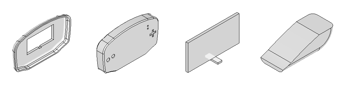

Reconstructed part sequence: 2, decoded part sequence: 1

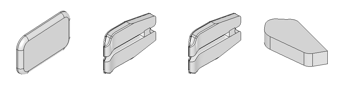

Reconstructed part sequence: 2, decoded part sequence: 2

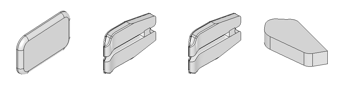

Reconstructed part sequence: 2, decoded part sequence: 3

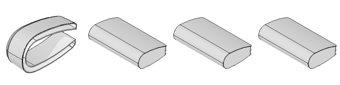

Reconstructed part sequence: 2, decoded part sequence: 4

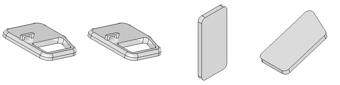

Reconstructed part sequence: 2, decoded part sequence: 5

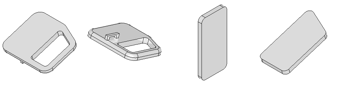

Reconstructed part sequence: 2, decoded part sequence: 6

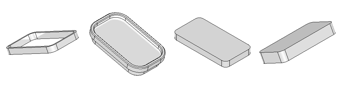

Reconstructed part sequence: 2, decoded part sequence: 7

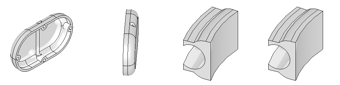

Reconstructed part sequence: 2, decoded part sequence: 8

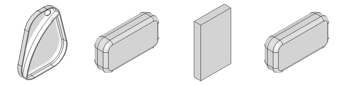

Reconstructed part sequence: 2, decoded part sequence: 9

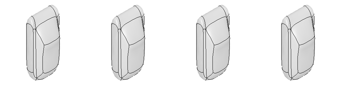

In [61]:
vid = '00'
rec_seq_idx = 2
for dec_seq_idx in range(10):
    img_md_list = []
    for img_idx in all_decoded_seq_list[rec_seq_idx][dec_seq_idx]:
        img_md = all_md[img_idx]
        img_md_list.append(img_md)

        img_name_list = extend_metadata_to_filepath(img_md_list, vid)

    display_image_grid(f'Reconstructed part sequence: {rec_seq_idx}, decoded part sequence: {dec_seq_idx}', img_name_list)

## Corresponding to 1. 

Original part sequence: 6

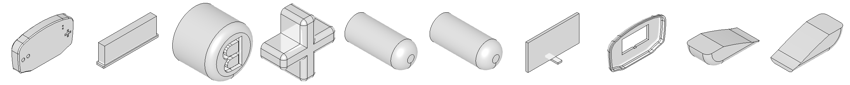

Decoded part sequence: 6

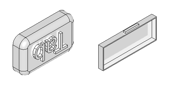

In [84]:
vid = '00'
rec_seq_idx = 6

img_md_list = []
for img_idx in all_ori_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Original part sequence: {rec_seq_idx}', img_name_list)

# vid = '00'
# rec_seq_idx = 79

img_md_list = []
for img_idx in all_rec_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Decoded part sequence: {rec_seq_idx}', img_name_list)

In [34]:
print(a[:10])

[('57104_f2f9baa4', ([116815], 0.1634666919708252)), ('23379_636204a6', ([58998, 59018, 59023], 0.17525952557722727)), ('52366_63042db4', ([108522, 108519, 108505], 0.17562739054361978)), ('34672_301d66e9', ([86659, 86655, 86656], 0.1800454705953598)), ('20533_0a3e112b', ([47199, 47198, 47191], 0.1817020426193873)), ('144653_e3eccdf1', ([40133, 40149, 40157], 0.1825626144806544)), ('55342_4090e441', ([113902], 0.18277797102928162)), ('145851_31817d8b', ([42224, 42244, 42377], 0.18641691406567892)), ('24258_841cc416', ([63834, 63813, 63812], 0.18648934861024222)), ('24225_50215341', ([63258, 63286, 63246], 0.18715993563334146))]


In [48]:
len(all_md)

141245

In [47]:
target = all_ori_closest_emb_list[3]

In [50]:
for res in a:
    if res[1][0][0] == target[0]:
        print(res[1][1])

## Corresponding to 3. 

[96138, 96139, 96140, 96141, 96142, 96143, 96144, 96145, 96146, 96147, 96148, 96149, 96150, 96151, 96152]


decoded part sequence: 0, average distance: 0.13709620758891106, assembly id: 41931_cd6dd23b

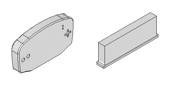

 
 
[88985, 88986, 88987, 88988, 88989, 88990, 88991, 88992]


decoded part sequence: 1, average distance: 0.15927467495203018, assembly id: 36409_3adb6194

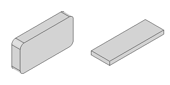

 
 
[77449, 77450, 77451, 77452, 77453, 77454, 77455, 77456, 77457, 77458, 77459, 77460, 77461, 77462, 77463, 77464, 77465, 77466, 77467, 77468, 77469, 77470, 77471, 77472, 77473, 77474]


decoded part sequence: 2, average distance: 0.15980016440153122, assembly id: 31388_0d7a2c35

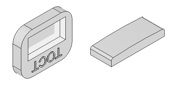

 
 
[139677, 139678, 139679, 139680, 139681, 139682, 139683, 139684, 139685, 139686, 139687, 139688, 139689, 139690, 139691, 139692, 139693, 139694, 139695, 139696, 139697, 139698, 139699, 139700, 139701, 139702, 139703, 139704, 139705, 139706, 139707, 139708, 139709, 139710, 139711, 139712, 139713, 139714, 139715, 139716, 139717, 139718, 139719, 139720, 139721, 139722, 139723, 139724]


decoded part sequence: 3, average distance: 0.16053612157702446, assembly id: 96961_37c427cc

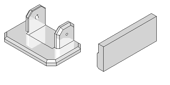

 
 
[133527, 133528, 133529, 133530, 133531, 133532, 133533, 133534, 133535, 133536, 133537, 133538, 133539, 133540, 133541, 133542, 133543, 133544, 133545, 133546, 133547, 133548, 133549, 133550, 133551, 133552, 133553, 133554, 133555, 133556]


decoded part sequence: 4, average distance: 0.16086462140083313, assembly id: 84374_272a9731

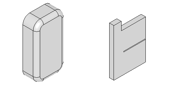

 
 
[115407, 115408, 115409, 115410, 115411, 115412, 115413, 115414, 115415, 115416, 115417, 115418, 115419, 115420, 115421, 115422, 115423, 115424, 115425, 115426, 115427, 115428]


decoded part sequence: 5, average distance: 0.16277246922254562, assembly id: 56165_ecd50749

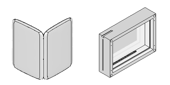

 
 
[92140, 92141, 92142, 92143, 92144, 92145, 92146, 92147, 92148, 92149, 92150, 92151, 92152, 92153, 92154]


decoded part sequence: 6, average distance: 0.16428882628679276, assembly id: 39105_9b5e7762

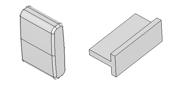

 
 
[113085, 113086, 113087, 113088, 113089, 113090, 113091, 113092, 113093, 113094, 113095, 113096, 113097, 113098, 113099, 113100, 113101, 113102, 113103, 113104, 113105, 113106, 113107, 113108, 113109, 113110, 113111, 113112, 113113, 113114, 113115, 113116, 113117, 113118, 113119, 113120, 113121, 113122, 113123, 113124, 113125, 113126, 113127]


decoded part sequence: 7, average distance: 0.16462428867816925, assembly id: 55015_a79e0d2e

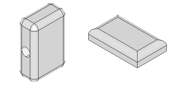

 
 
[44630, 44631, 44632, 44633, 44634, 44635, 44636, 44637, 44638, 44639, 44640, 44641, 44642, 44643, 44644, 44645, 44646, 44647, 44648, 44649, 44650, 44651, 44652, 44653, 44654, 44655, 44656, 44657, 44658, 44659, 44660, 44661, 44662, 44663, 44664]


decoded part sequence: 8, average distance: 0.16573938727378845, assembly id: 146889_355637a1

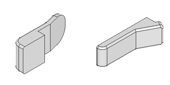

 
 
[26873, 26874, 26875, 26876, 26877, 26878, 26879, 26880, 26881, 26882, 26883, 26884, 26885, 26886, 26887, 26888, 26889, 26890, 26891, 26892, 26893, 26894, 26895, 26896, 26897, 26898, 26899, 26900, 26901, 26902, 26903, 26904, 26905, 26906, 26907, 26908, 26909, 26910, 26911, 26912, 26913, 26914, 26915, 26916, 26917, 26918, 26919, 26920, 26921, 26922, 26923, 26924, 26925, 26926, 26927, 26928, 26929, 26930, 26931, 26932, 26933, 26934, 26935, 26936, 26937, 26938, 26939, 26940, 26941, 26942, 26943, 26944, 26945, 26946, 26947, 26948, 26949, 26950, 26951, 26952, 26953, 26954, 26955, 26956, 26957, 26958, 26959, 26960, 26961, 26962, 26963, 26964, 26965, 26966, 26967, 26968, 26969, 26970, 26971, 26972, 26973, 26974, 26975, 26976, 26977, 26978, 26979, 26980, 26981, 26982, 26983, 26984, 26985, 26986, 26987, 26988, 26989, 26990, 26991, 26992, 26993, 26994, 26995, 26996, 26997, 26998, 26999, 27000, 27001, 27002, 27003, 27004, 27005]


decoded part sequence: 9, average distance: 0.1660975068807602, assembly id: 135842_03e5ca3f

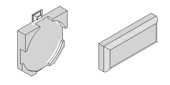

 
 
[93710, 93711, 93712, 93713, 93714, 93715, 93716, 93717, 93718, 93719, 93720, 93721, 93722, 93723, 93724, 93725, 93726, 93727, 93728, 93729, 93730, 93731, 93732, 93733, 93734, 93735, 93736, 93737, 93738, 93739, 93740, 93741, 93742, 93743, 93744, 93745, 93746, 93747]


decoded part sequence: 10, average distance: 0.1661815494298935, assembly id: 41306_8f26e703

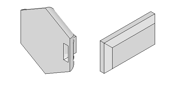

 
 
[57553, 57554, 57555, 57556, 57557, 57558, 57559, 57560, 57561, 57562, 57563, 57564, 57565, 57566, 57567, 57568, 57569, 57570, 57571, 57572, 57573, 57574, 57575, 57576, 57577, 57578, 57579, 57580, 57581, 57582, 57583, 57584, 57585, 57586, 57587, 57588, 57589, 57590, 57591, 57592]


decoded part sequence: 11, average distance: 0.1669505089521408, assembly id: 23168_7fdf5427

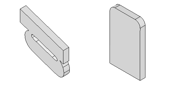

 
 
[21465, 21466, 21467, 21468, 21469, 21470, 21471]


decoded part sequence: 12, average distance: 0.16808480769395828, assembly id: 132863_90d729e2

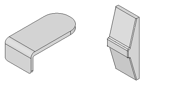

 
 
[134186, 134187, 134188, 134189, 134190, 134191, 134192, 134193, 134194, 134195, 134196, 134197, 134198, 134199, 134200, 134201, 134202]


decoded part sequence: 13, average distance: 0.1681070327758789, assembly id: 86278_1e55d036

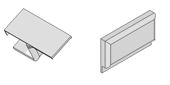

 
 
[18152, 18153, 18154, 18155, 18156, 18157, 18158, 18159, 18160, 18161, 18162, 18163, 18164, 18165, 18166, 18167, 18168, 18169, 18170, 18171, 18172, 18173, 18174, 18175, 18176, 18177, 18178, 18179, 18180, 18181, 18182, 18183, 18184, 18185, 18186, 18187, 18188, 18189, 18190, 18191, 18192, 18193, 18194, 18195, 18196, 18197, 18198, 18199, 18200, 18201, 18202, 18203]


decoded part sequence: 14, average distance: 0.16821984201669693, assembly id: 131100_0424791a

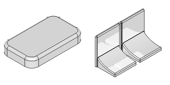

 
 
[39389, 39390, 39391, 39392, 39393, 39394, 39395, 39396, 39397, 39398, 39399, 39400, 39401, 39402, 39403, 39404, 39405, 39406, 39407]


decoded part sequence: 15, average distance: 0.16881974786520004, assembly id: 144137_6661eed3

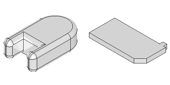

 
 
[95568, 95569, 95570, 95571, 95572, 95573, 95574, 95575, 95576, 95577, 95578, 95579, 95580, 95581, 95582, 95583, 95584, 95585, 95586, 95587]


decoded part sequence: 16, average distance: 0.1692172810435295, assembly id: 41852_ca66b6b4

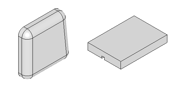

 
 
[55861, 55862, 55863, 55864, 55865, 55866, 55867, 55868, 55869, 55870, 55871, 55872, 55873, 55874, 55875, 55876, 55877, 55878, 55879, 55880, 55881, 55882, 55883, 55884, 55885, 55886, 55887, 55888, 55889, 55890, 55891, 55892, 55893, 55894, 55895, 55896, 55897, 55898, 55899, 55900, 55901, 55902]


decoded part sequence: 17, average distance: 0.16937865316867828, assembly id: 22852_dc1dbed6

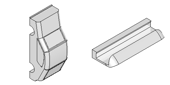

 
 
[81903, 81904, 81905, 81906, 81907, 81908, 81909, 81910, 81911, 81912, 81913, 81914, 81915, 81916, 81917, 81918, 81919, 81920, 81921, 81922, 81923, 81924, 81925, 81926, 81927, 81928, 81929, 81930, 81931, 81932, 81933, 81934, 81935, 81936, 81937, 81938, 81939, 81940, 81941, 81942, 81943, 81944, 81945, 81946, 81947]


decoded part sequence: 18, average distance: 0.16975325345993042, assembly id: 32895_6140d821

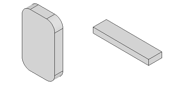

 
 
[115695, 115696, 115697, 115698, 115699, 115700, 115701, 115702, 115703, 115704, 115705, 115706, 115707, 115708, 115709, 115710, 115711, 115712, 115713, 115714, 115715, 115716, 115717]


decoded part sequence: 19, average distance: 0.16981973499059677, assembly id: 56353_ad819cb6

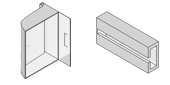

In [83]:
rec_seq_idx = 6
decoded_seq = sorted(all_decoded_seq_list[rec_seq_idx].items(), key=lambda x: x[1][1])
# print(decoded_seq[:20])

vid = '00'
for dec_seq_idx, (aid, (indices, avg_dist)) in enumerate(decoded_seq[:20]):
    img_md_list = []
    print(aid_to_part_indice_map[aid])
    for index in indices:
        img_md = all_md[index]
        img_md_list.append(img_md)

        img_name_list = extend_metadata_to_filepath(img_md_list, vid)

    display_image_grid(f'decoded part sequence: {dec_seq_idx}, average distance: {avg_dist}, assembly id: {aid}', img_name_list)

38


decoded part sequence: 0, average distance: 0.25085414946079254, assembly id: 20176_a02bde39

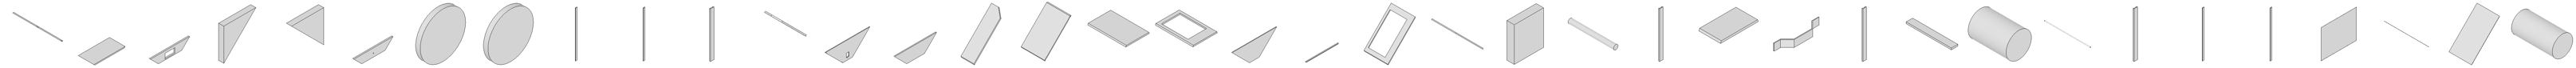

In [102]:
vid = '00'
rec_seq_idx = 49
img_md_list = []
for i, index in enumerate(indices):
    img_md = all_md[index]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)
print(len(img_name_list))

display_image_grid(f'decoded part sequence: {dec_seq_idx}, average distance: {avg_dist}, assembly id: {aid}', img_name_list)

In [ ]:
indices

In [58]:
aid_to_part_indice_map['114349_2774708d']

[7286, 7287, 7288, 7289]